# Téléchargement du Dataset

Pour télécharger le dataset, exécuté la commande suivante dans le terminal :
```bash
python -m trafficsigns.data.download
```

# Dataset

Pour ce projet, nous allons utiliser le dataset GTSRB -German Traffics Signs Recognition Benchmark-. Voici ses informations :
- Auteur : Mykola
- License : CC0: Public Domain

In [8]:
import numpy as np
import pandas as pd
import os
import trafficsigns.data.observe_dataset as obs
from pathlib import Path

path_to_files = os.path.join(os.getcwd(), '..', "..", "data", "raw", "gtsrb")

data_frame = pd.read_csv(filepath_or_buffer=os.path.join(path_to_files, "Train.csv"))

print("== Head des données brutes ==")
print(data_frame.head(5))


print(f"Taille du dataset d'entrainement : {len(data_frame)}")

== Head des données brutes ==
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  
Taille du dataset d'entrainement : 39209


In [9]:
correspondance = {
    0: "Limite de vitesse (20 km/h)",
    1: "Limite de vitesse (30 km/h)",
    2: "Limite de vitesse (50 km/h)",
    3: "Limite de vitesse (60 km/h)",
    4: "Limite de vitesse (70 km/h)",
    5: "Limite de vitesse (80 km/h)",
    6: "Fin de limitation de vitesse (80 km/h)",
    7: "Limite de vitesse (100 km/h)",
    8: "Limite de vitesse (120 km/h)",
    9: "Interdiction de dépasser",
    10: "Interdiction de dépasser pour les véhicules > 3.5 t",
    11: "Interdiction d'intersection / Priorité à la prochaine intersection",
    12: "Route prioritaire",
    13: "Cédez le passage",
    14: "Stop",
    15: "Circulation interdite à tout véhicule dans les deux sens",
    16: "Interdiction d'accès aux véhicules > 3.5 t",
    17: "Sens interdit",
    18: "Danger",
    19: "Virage à gauche",
    20: "Virage à droite",
    21: "Successions de virages",
    22: "Casserole / Route bosselée",
    23: "Chaussée glissante",
    24: "Rétrécissement de la chaussée par la droite",
    25: "Travaux en cours",
    26: "Signaux lumineux / Feux tricolores",
    27: "Passage de piétons",
    28: "Attention enfants",
    29: "Passage de cyclistes",
    30: "Danger neige / verglas",
    31: "Passage d'animaux sauvages",
    32: "Fin de toutes les interdictions précédemment signalées",
    33: "Obligation de tourner à droite",
    34: "Obligation de tourner à gauche",
    35: "Obligation d'aller tout droit",
    36: "Obligation d'aller tout droit ou à droite",
    37: "Obligation d'aller tout droit ou à gauche",
    38: "Contournement obligatoire par la droite",
    39: "Contournement obligatoire par la gauche",
    40: "Rond-point",
    41: "Fin d'interdiction de dépasser",
    42: "Fin d'interdiction de dépasser pour les véhicules > 3.5 t",
}

## Description des classes

| ClassID | Signification du panneau |
| --- | --- |
| 0 | Limite de vitesse (20 km/h) |
| 1 | Limite de vitesse (30 km/h) |
| 2 | Limite de vitesse (50 km/h) |
| 3 | Limite de vitesse (60 km/h) |
| 4 | Limite de vitesse (70 km/h) |
| 5 | Limite de vitesse (80 km/h) |
| 6 | Fin de limitation de vitesse (80 km/h) |
| 7 | Limite de vitesse (100 km/h) |
| 8 | Limite de vitesse (120 km/h) |
| 9 | Interdiction de dépasser |
| 10 | Interdiction de dépasser pour les véhicules > 3.5 t |
| 11 | Interdiction d'intersection / Priorité à la prochaine intersection |
| 12 | Route prioritaire |
| 13 | Cédez le passage |
| 14 | Stop |
| 15 | Circulation interdite à tout véhicule dans les deux sens |
| 16 | Interdiction d'accès aux véhicules > 3.5 t |
| 17 | Sens interdit |
| 18 | Danger |
| 19 | Virage à gauche |
| 20 | Virage à droite |
| 21 | Successions de virages |
| 22 | Casserole / Route bosselée |
| 23 | Chaussée glissante |
| 24 | Rétrécissement de la chaussée par la droite |
| 25 | Travaux en cours |
| 26 | Signaux lumineux / Feux tricolores |
| 27 | Passage de piétons |
| 28 | Attention enfants |
| 29 | Passage de cyclistes |
| 30 | Danger neige / verglas |
| 31 | Passage d'animaux sauvages |
| 32 | Fin de toutes les interdictions précédemment signalées |
| 33 | Obligation de tourner à droite |
| 34 | Obligation de tourner à gauche |
| 35 | Obligation d'aller tout droit |
| 36 | Obligation d'aller tout droit ou à droite |
| 37 | Obligation d'aller tout droit ou à gauche |
| 38 | Contournement obligatoire par la droite |
| 39 | Contournement obligatoire par la gauche |
| 40 | Rond-point |
| 41 | Fin d'interdiction de dépasser |
| 42 | Fin d'interdiction de dépasser pour les véhicules > 3.5 t |

In [10]:
print("== Quantités de chaque classe du dataset d'entrainement ==")

quantity_frame = obs.get_quantity_of_class(data_frame, "ClassId")
print(quantity_frame)

print(f"Nombre de classes : {len(quantity_frame)}")


== Quantités de chaque classe du dataset d'entrainement ==
    ClassID  Quantité
0        20       360
1         0       210
2         1      2220
3         2      2250
4         3      1410
5         4      1980
6         5      1860
7         6       420
8         7      1440
9         8      1410
10        9      1470
11       10      2010
12       11      1320
13       12      2100
14       13      2160
15       14       780
16       15       630
17       16       420
18       17      1110
19       18      1200
20       19       210
21       21       330
22       22       390
23       23       510
24       24       270
25       25      1500
26       26       600
27       27       240
28       28       540
29       29       270
30       30       450
31       31       780
32       32       240
33       33       689
34       34       420
35       35      1200
36       36       390
37       37       210
38       38      2070
39       39       300
40       40       360
41       41      

== Informations sur la taille des images ==
         Hauteur  Largeur
Minimum     25.0     25.0
Median      43.0     43.0
Maximum    225.0    243.0


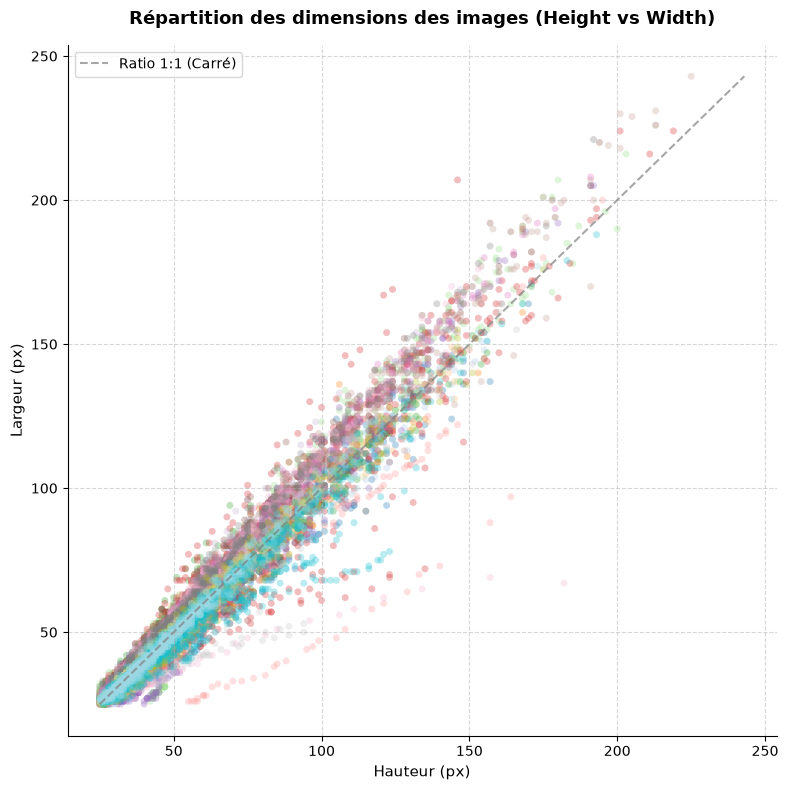

In [11]:
print("== Informations sur la taille des images ==")

size_dataframe = pd.DataFrame({"Hauteur" : [data_frame['Height'].min(), np.median(np.array(data_frame['Height'])), data_frame['Height'].max()], "Largeur" : [data_frame['Width'].min(), np.median(np.array(data_frame['Width'])), data_frame['Width'].max()]}, index=["Minimum", "Median", "Maximum"])
print(size_dataframe)

obs.get_size_of_images_plot(data_frame)


In [7]:
obs.get_size_plot(quantity_frame)

NameError: name 'quantity_frame' is not defined

## Déséquilibre des classes

Le déséquilibre se fait entre la classe "Limite de vitesse à 50km/h" et la classe "Limite de vitesse à 20km/h".

In [ ]:
biggest_class = quantity_frame[quantity_frame['Quantité'].max() == quantity_frame['Quantité']]
smallest_class = quantity_frame[quantity_frame['Quantité'].min() == quantity_frame['Quantité']]

ratio = biggest_class['Quantité'].unique()[0]/smallest_class['Quantité'].unique()[0]

print("="*50)
print("Déséquilibre des classes")
print(f"- Ratio entre la classe {biggest_class['ClassID'].unique()[0]} et la classe {smallest_class['ClassID'].unique()[0]}:  {ratio:.2f}:1")


## Format des fichiers

- png
- RGB
- 3 Canaux

In [ ]:
obs.analyze_dataset(Path("./").resolve().parent.parent / "data/raw/gtsrb/Train")

In [12]:

mean, std = obs.get_mean_std(Path("./").resolve().parent.parent / "data/raw/gtsrb/Train")

print("\n--- RÉSULTATS ---")
print(f"mean = [{mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f}]")
print(f"std  = [{std[0]:.4f}, {std[1]:.4f}, {std[2]:.4f}]")

Calcul en cours sur 39209 images...

--- RÉSULTATS ---
mean = [0.3403, 0.3122, 0.3214]
std  = [0.2751, 0.2642, 0.2706]


# Planche d'aperçus

In [ ]:
obs.create_frame(Path("./").resolve().parent.parent / "data/raw/gtsrb/Train", correspondance, save_path=Path("./").resolve().parent.parent / "reports/figures/planche_classes.png")

In [ ]:
obs.create_every_class_frame(Path("./").resolve().parent.parent / "data/raw/gtsrb/Train", correspondance, save_dir=Path("./").resolve().parent.parent / "reports/figures/detailed_classes")